# **04 Análise de sobrevivência**

---

#### Este arquivo é responsável pela análise de sobrevivência dos funcionários, buscando identificar quais fatores aumentam ou reduzem o risco de desligamento ao longo do tempo

## Perguntas e variáveis análisadas

- Qual a probabilidade de permanência dos funcionários ao longo dos anos ?
- Funcionários que fazem hora extra possuem maior risco de desligamento ?
- O salário influencia no tempo de permanência na empresa ?
- Quais variáveis possuem maior impacto sobre o risco de demissão ?

---

# Código:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

df = pd.read_csv('../data/tabela_base_traduzida.csv')

sns.set_theme(style = "darkgrid", palette = "cividis", context = "notebook")

### **Análise de sobrevivência global**

Qual a probabilidade de permanência dos funcionários ao longo dos anos ?

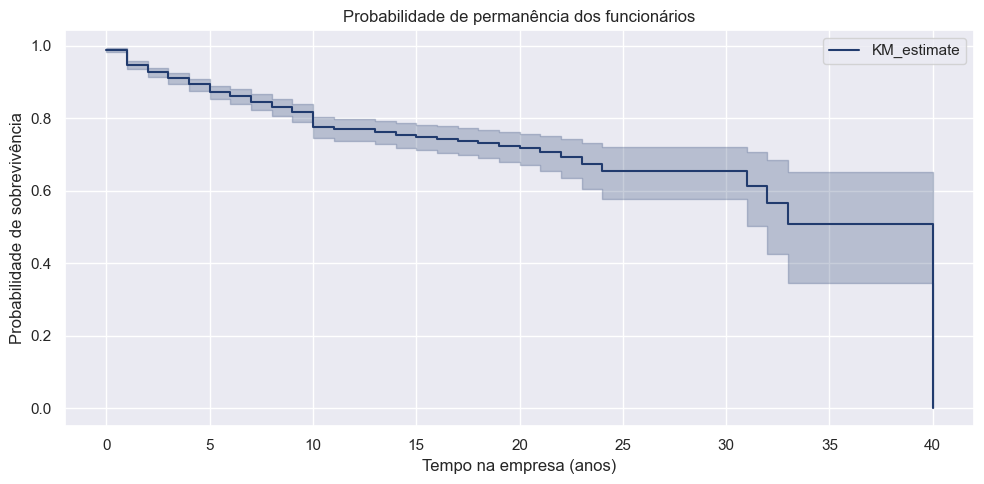

In [4]:
# Criando evento onde: 0: Não aconteceu | 1: Aconteceu
df["Evento"] = df["Demitido"].map({ "No": 0, "Yes": 1})

# chamando o objo KaplanMeier, funciona como uma variável vazia que receberá os eventos
kmf = KaplanMeierFitter()

# Por quanto tempo um evento será analisado
kmf.fit(
    durations = df["Anos_na_Empresa"],
    event_observed = df["Evento"]
)

plt.figure(figsize = (10, 5))
kmf.plot_survival_function()

plt.title("Probabilidade de permanência dos funcionários")
plt.xlabel("Tempo na empresa (anos)")
plt.ylabel("Probabilidade de sobrevivência")

plt.tight_layout()
plt.show()

### **Análise de horas extras**

Funcionários que realizam horas extras apresentam maior risco de desligamento ?

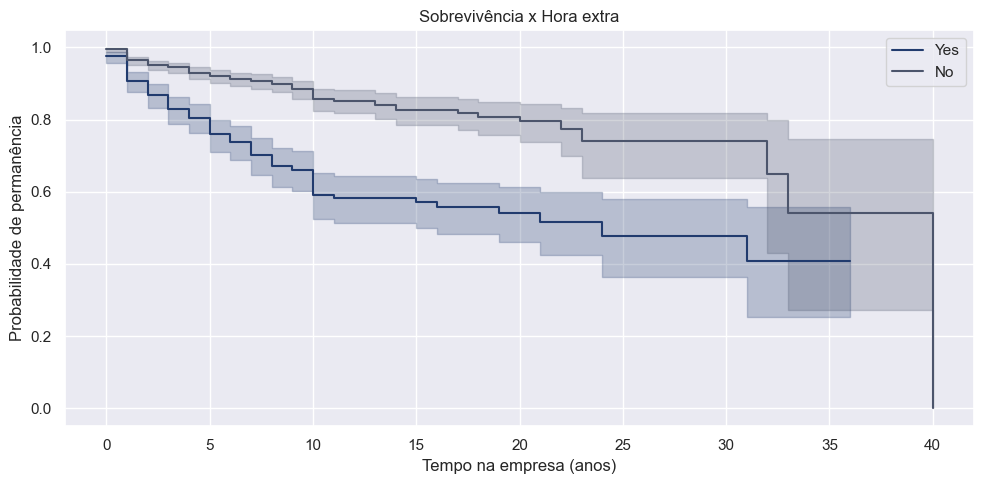

In [5]:
fig, ax = plt.subplots(figsize = (10, 5))

# chamando o objo KaplanMeier, funciona como uma variável vazia que receberá os eventos
kmf = KaplanMeierFitter()

# Percorrendo cada grupo de hora extra existente na base
for grupo in df["Hora_Extra"].unique():
    
    # Filtrando apenas os funcionários do grupo atual
    filtro = df["Hora_Extra"] == grupo
    
    # Calculando a sobrevivência para o grupo filtrado
    kmf.fit(
        durations = df[filtro]["Anos_na_Empresa"],
        event_observed = df[filtro]["Evento"],
        label = grupo
    )
    
    # Adicionando a curva de sobrevivência ao gráfico
    kmf.plot_survival_function(ax = ax)

ax.set_title("Sobrevivência x Hora extra")
ax.set_xlabel("Tempo na empresa (anos)")
ax.set_ylabel("Probabilidade de permanência")

plt.tight_layout()
plt.show()

### **Análise salarial**

Funcionários com salários maiores permanecem mais tempo na empresa ?

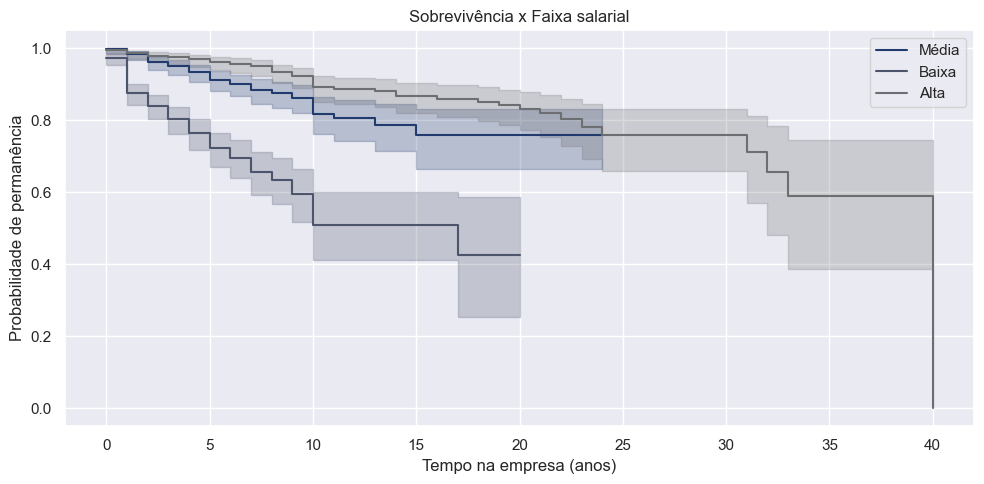

In [6]:
# Separando os funcionários em três faixas salariais
df["Faixa_Salarial"] = pd.qcut(df["Renda_Mensal"], q = 3, labels = ["Baixa", "Média", "Alta"])

fig, ax = plt.subplots(figsize = (10, 5))

# Percorrendo cada faixa salarial criada
for grupo in df["Faixa_Salarial"].unique():
    
    # Filtrando os funcionários da faixa salarial atual
    filtro = df["Faixa_Salarial"] == grupo
    
    # Calculando a probabilidade de permanência da faixa salarial
    kmf.fit(
        durations = df[filtro]["Anos_na_Empresa"],
        event_observed = df[filtro]["Evento"],
        label = grupo
    )
    
    # Adicionando a curva de sobrevivência ao gráfico
    kmf.plot_survival_function(ax = ax)

ax.set_title("Sobrevivência x Faixa salarial")
ax.set_xlabel("Tempo na empresa (anos)")
ax.set_ylabel("Probabilidade de permanência")

plt.tight_layout()
plt.show()

### **Modelo de riscos proporcionais de Cox**

Quais variáveis possuem maior impacto sobre o risco de desligamento ?


In [7]:
# Selecionando aas variáveis que serão utilizadas no modelo de Cox
df_cox = df[[
    "Anos_na_Empresa",
    "Evento",
    "Idade",
    "Renda_Mensal",
    "Razão_salarial",
    "Satisfação_geral",
    "Total_Anos_Trabalhados",
    "Anos_no_Cargo_Atual"
]].copy()

# chamando o objo CoxPHFitter, funciona como uma variável vazia que receberá os dados do modelo
cox = CoxPHFitter()

# Treinando o modelo com o tempo de permanência e a ocorrência do evento
cox.fit(
    df_cox,
    duration_col = "Anos_na_Empresa",
    event_col = "Evento"
)

# Exibindo o resumo estatístico do modelo
cox.print_summary()

<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'Anos_na_Empresa'
                event col = 'Evento'
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1349.56
         time fit was run = 2026-06-13 18:50:59 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Idade                  -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Renda_Mensal            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Razão_salarial          0.45      1.56      0.09            0.26            0.63                1.30                1.88
Satisfação_geral       -0.20      0.82      0.03           -0.26           -0.14                0.77                0.87
Total_Anos_Trabalhados -0.17      0.84      0.03           -0.23           -0.12                0.80                0.89
Anos_no_Cargo_Atual    -0.27      0.76      0.03           -0.33           -0.21                0.72                0.81

                        cmp to     z      p  -log2(p)
covariate                                            
Idade                     0.00 -0.17   0.87      0.21
Renda_Mensal              0.00  0.98   0.33      1.61
Razão_salarial            0.00  4.77 <0.005     19.03
Satisfação_geral          0.00 -6.11 <0.005     29.89
Total_Anos_Trabalhados    0.00 -6.45 <0.005     33.01
Anos_no_Cargo_Atual       0.00 -9.29 <0.005     65.88
---
Concordance = 0.88
Partial AIC = 2711.12
log-likelihood ratio test = 449.12 on 6 df
-log2(p) of ll-ratio test = 309.34

### **Ranking das variáveis mais importantes**

Quanto maior o valor absoluto do coeficiente, maior o impacto da variável no risco de desligamento.

In [8]:
# Ordenando as variáveis pelo nível de impacto no modelo
ranking = (
    cox.params_
    .abs()
    .sort_values(ascending = False)
)

print(ranking)

covariate
Razão_salarial            0.447883
Anos_no_Cargo_Atual       0.268535
Satisfação_geral          0.200536
Total_Anos_Trabalhados    0.172641
Idade                     0.001762
Renda_Mensal              0.000035
Name: coef, dtype: float64
